In [1]:
import glob
import math
import numpy as np
import uproot
import hist
import awkward as ak
import vector
import matplotlib.pyplot as plt
import mplhep as hep
from tqdm.auto import tqdm

vector.register_awkward()
hep.style.use("CMS")

/home/achihwan/miniconda3/envs/hep-py-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SIG_DIR   = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig"
NANO_BASE = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023"

WR_N_MAP = {
    2000: list(range(100, 2000, 200)),
    4000: list(range(100, 4000, 200)),
    6000: list(range(100, 6000, 200)),
    8000: list(range(100, 8000, 200)),
}

# Common bins for all WR: 200 GeV bins, 0-8000 GeV
REBIN = 200
BINS  = np.arange(0, 8200, REBIN)   # edges: [0, 200, 400, ..., 8000]

BOOSTED_CF  = "Central/Cutflow_for_Boosted_SR"
RESOLVED_CF = ["Central/Cutflow_for_Resolved_SR", "Central/Cutflow_for_reseolved_SR"]

COLOR_LHE      = "dimgray"
COLOR_BOOSTED  = "steelblue"
COLOR_RESOLVED = "tomato"

In [3]:
def get_lhe_mass(wr, n):
    """Read all NanoAOD files for (WR, N) and return summed LHE 4-vector mass array."""
    pattern = (
        f"{NANO_BASE}/WRtoNMutoMuMuJJ_MWR{wr}_N{n}_"
        f"TuneCP5_13p6TeV_madgraph-pythia8/**/*.root"
    )
    files = sorted(glob.glob(pattern, recursive=True))
    if not files:
        return np.array([])

    masses = []
    for fpath in files:
        root_file = uproot.open(fpath)
        for chunk in root_file["Events"].iterate(
            ["LHEPart_pt", "LHEPart_eta", "LHEPart_phi", "LHEPart_mass"],
            step_size="200 MB",
            library="ak",
        ):
            p4 = ak.zip(
                {
                    "pt":   chunk["LHEPart_pt"],
                    "eta":  chunk["LHEPart_eta"],
                    "phi":  chunk["LHEPart_phi"],
                    "mass": chunk["LHEPart_mass"],
                },
                with_name="Momentum4D",
            )
            m = ak.to_numpy(ak.sum(p4, axis=1).mass)
            masses.append(m[np.isfinite(m)])
    return np.concatenate(masses) if masses else np.array([])


def get_eff(wr, n, region):
    """Extract selection efficiency from cutflow histogram."""
    fpath = f"{SIG_DIR}/WR{wr}N{n}MM.root"
    try:
        with uproot.open(fpath) as f:
            if region == "boosted":
                if BOOSTED_CF not in f:
                    return np.nan
                vals  = f[BOOSTED_CF].values(flow=False)
                denom = float(vals[1])
                numer = float(vals[-2])   # penultimate = last signal bin
            else:
                cf_key = next((k for k in RESOLVED_CF if k in f), None)
                if cf_key is None:
                    return np.nan
                vals  = f[cf_key].values(flow=False)
                denom = float(vals[1])
                numer = float(vals[-1])
            return np.nan if denom <= 0 else numer / denom
    except (FileNotFoundError, OSError):
        return np.nan


def get_reco_vals(wr, n, branch):
    """Return (values, edges) for a reco histogram, rebinned to REBIN GeV."""
    fpath = f"{SIG_DIR}/WR{wr}N{n}MM.root"
    try:
        with uproot.open(fpath) as f:
            if branch not in f:
                return np.zeros(len(BINS) - 1), BINS
            h = f[branch].to_hist()[:: hist.rebin(REBIN)]
            return h.values(), h.axes[0].edges
    except (FileNotFoundError, OSError):
        return np.zeros(len(BINS) - 1), BINS

In [ ]:
import os

CACHE_DIR = os.path.join(
    "/data6/Users/achihwan/SKNanoAnalyzer-v13/plots/HNWR/singnal_sample/Offshell_test",
    "lhe_cache",
)

# ── Load LHE masses from condor-precomputed npz cache ────────────────────────
# First submit jobs:  bash submit_lhe.sh
# Wait for completion: condor_q $USER
# Then run this cell to load results.
#
# Missing cache files fall back to empty array (LHE not shown for that point).

lhe_cache = {}
missing = []

for wr, n_list in WR_N_MAP.items():
    for n in n_list:
        npz_path = f"{CACHE_DIR}/WR{wr}_N{n}.npz"
        if os.path.exists(npz_path):
            lhe_cache[(wr, n)] = np.load(npz_path)["mass"]
        else:
            lhe_cache[(wr, n)] = np.array([])
            missing.append((wr, n))

total = sum(len(v) for v in WR_N_MAP.values())
print(f"Loaded {total - len(missing)}/{total} cache files from {CACHE_DIR}")
if missing:
    print(f"Missing ({len(missing)}): {missing[:10]}{'...' if len(missing) > 10 else ''}")
    print("→ Run:  bash submit_lhe.sh")

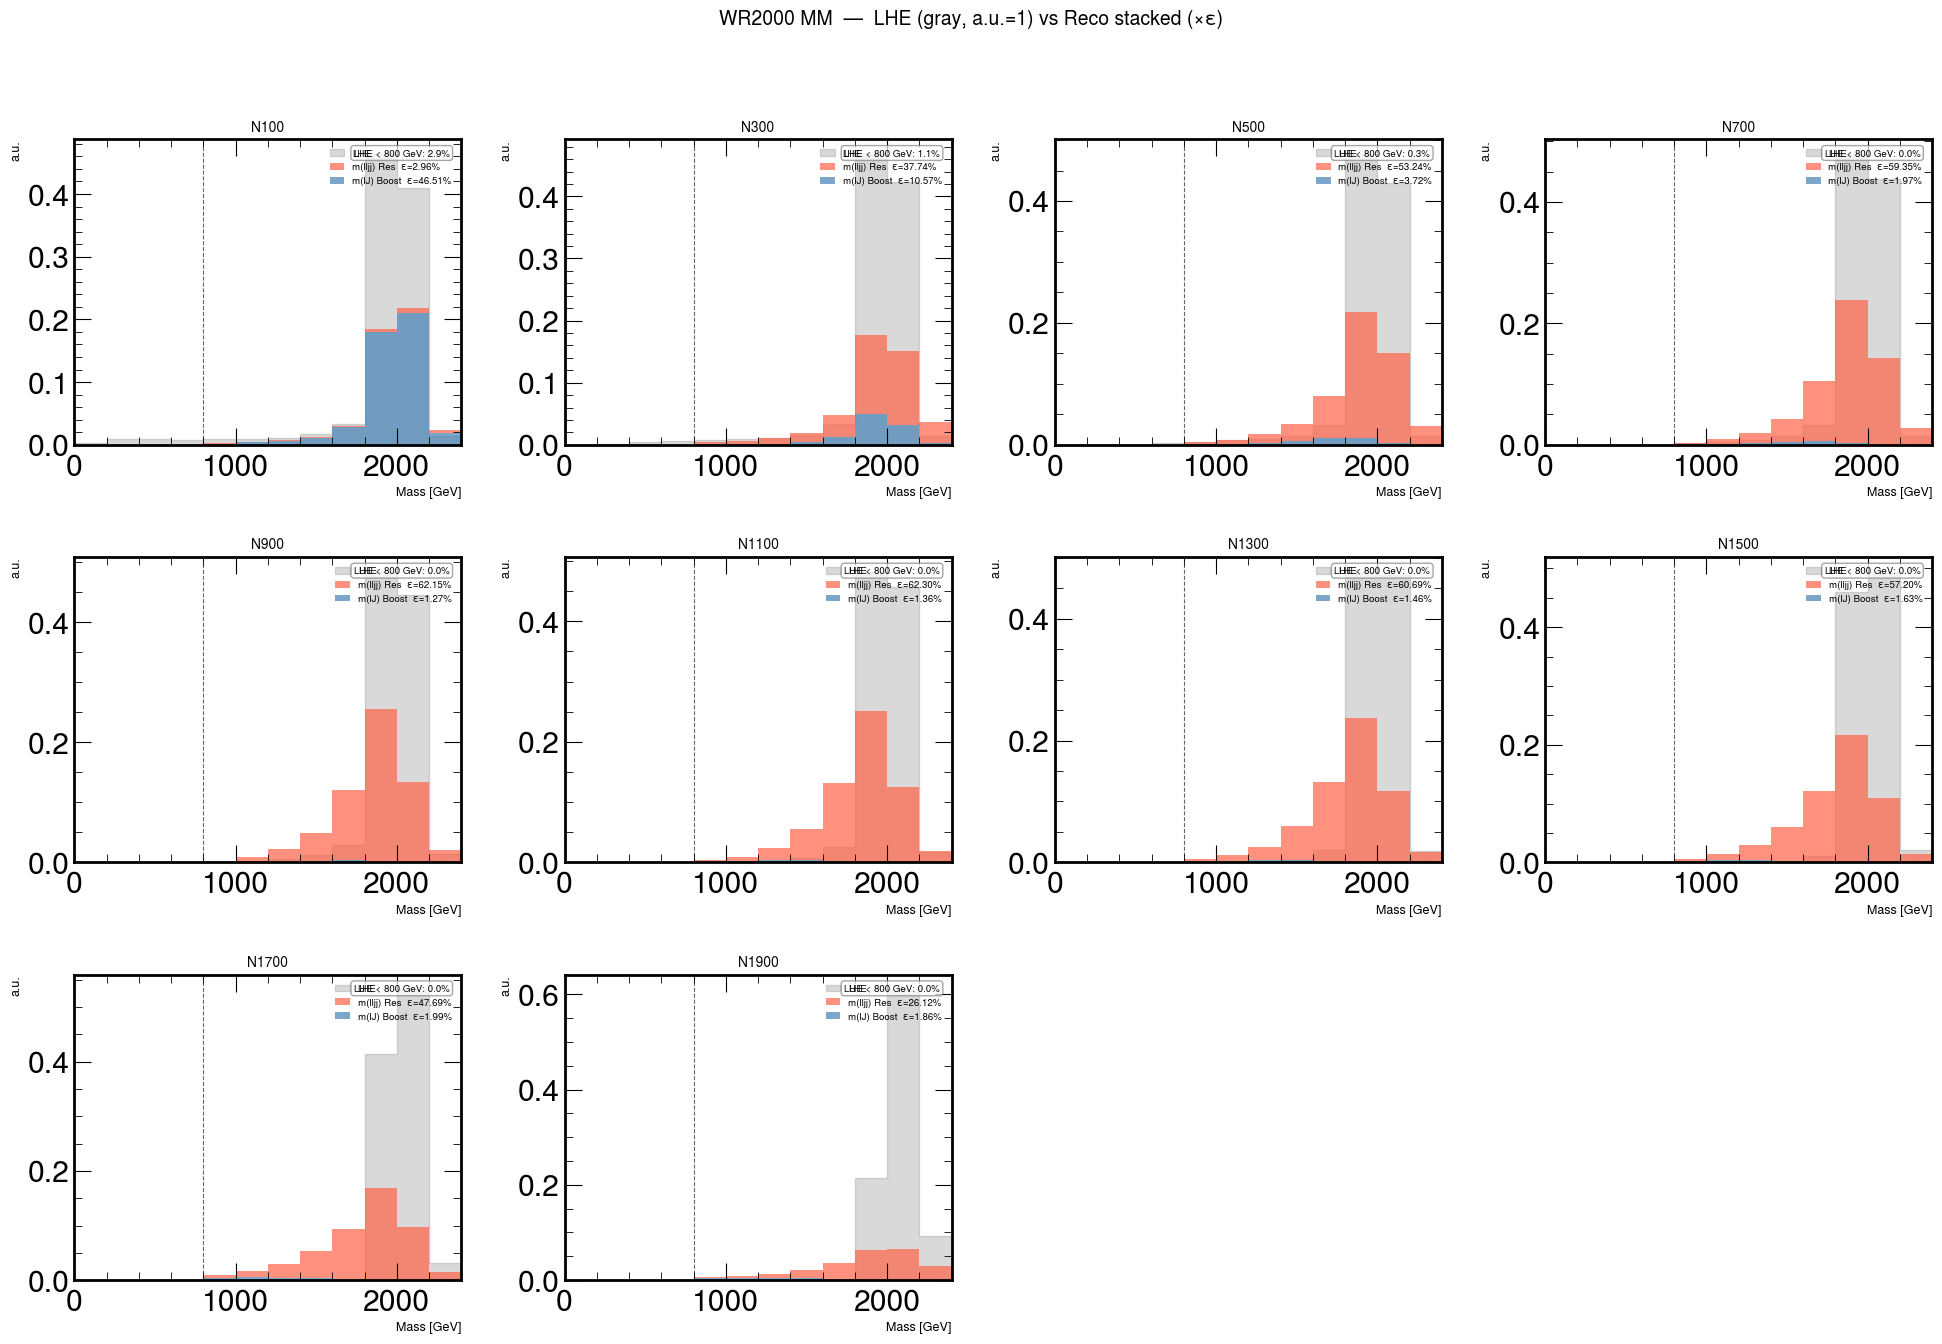

Saved WR2000_MM_lhe_vs_reco_stacked.png


KeyError: (4000, 300)

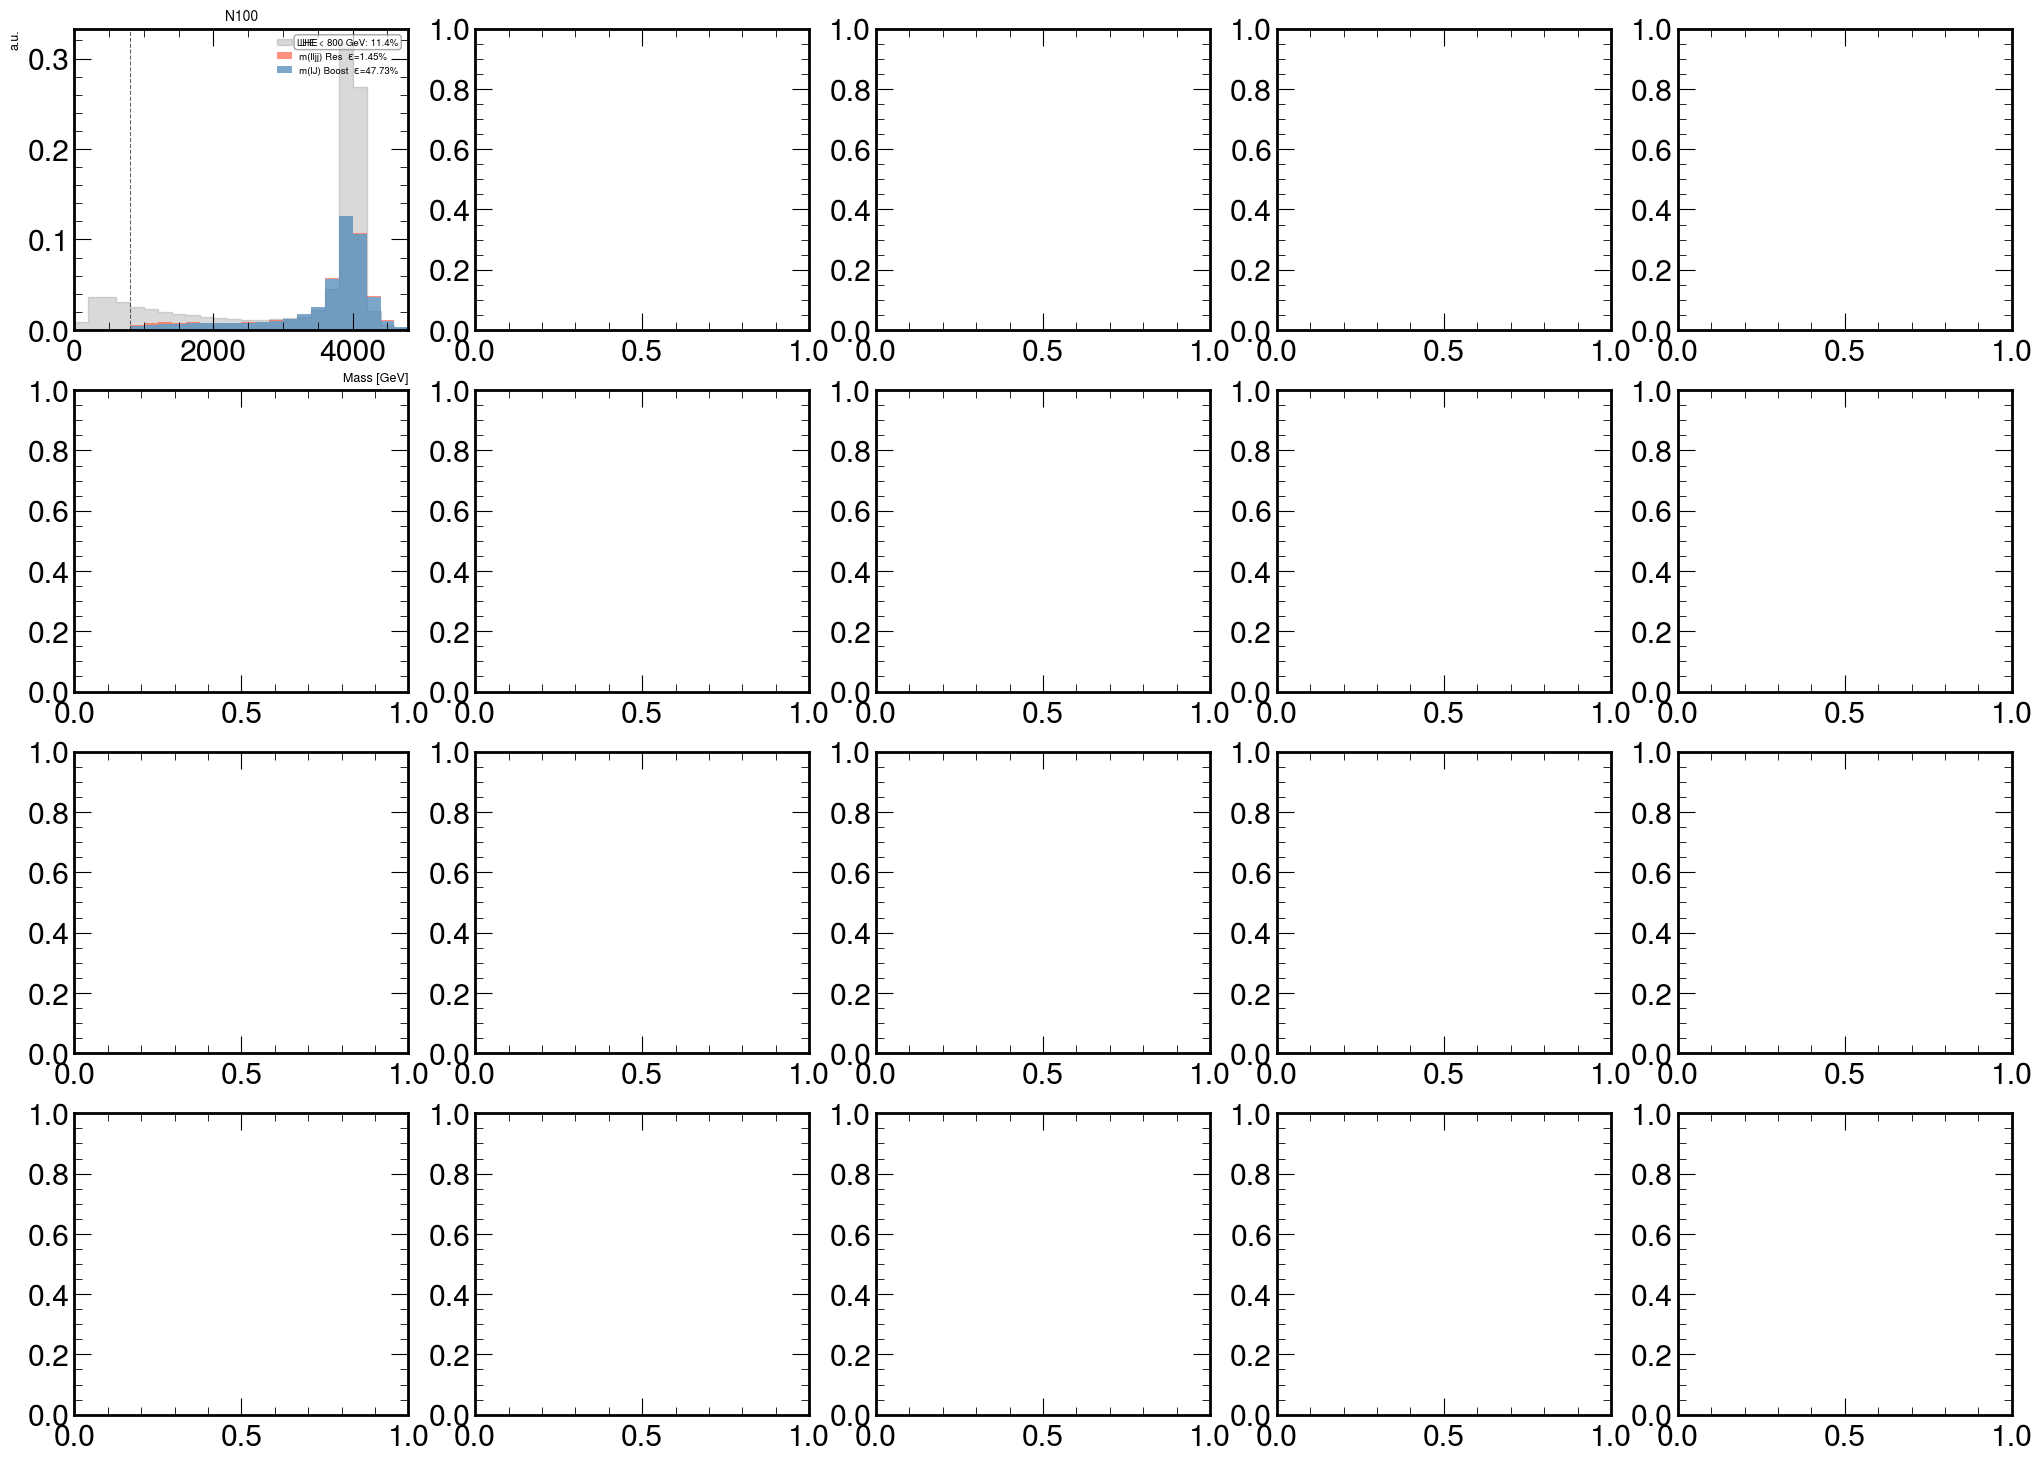

In [6]:
for wr, n_list in WR_N_MAP.items():
    n_plots = len(n_list)
    ncols   = math.ceil(math.sqrt(n_plots))
    nrows   = math.ceil(n_plots / ncols)
    x_max   = wr * 1.2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 5, nrows * 4.5),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i, n in enumerate(n_list):
        ax = axes_flat[i]

        # ── LHE (normalized to 1, transparent fill) ──────────────────────
        lhe = lhe_cache[(wr, n)]
        if len(lhe) > 0:
            lhe_vals, _ = np.histogram(lhe, bins=BINS)
            s = lhe_vals.sum()
            lhe_norm = lhe_vals / s if s > 0 else lhe_vals
            hep.histplot(
                lhe_norm, bins=BINS, ax=ax,
                histtype="fill",
                color=COLOR_LHE, alpha=0.25, linewidth=1, edgecolor=COLOR_LHE,
                label="LHE",
            )
            # fraction below 800 GeV
            frac_below_800 = np.count_nonzero(lhe < 800) / len(lhe)
            ax.text(
                0.97, 0.97,
                f"LHE < 800 GeV: {frac_below_800:.1%}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="gray"),
            )
        else:
            frac_below_800 = np.nan

        # ── Reco Boosted  m(lJ):  normalize to a.u. then × ε_B ───────────
        b_vals, b_edges = get_reco_vals(wr, n, "Central/SR_Boosted_MM_mlljj")
        eff_b = get_eff(wr, n, "boosted")
        b_s   = b_vals.sum()
        b_scaled = (
            b_vals / b_s * eff_b
            if (b_s > 0 and not np.isnan(eff_b))
            else np.zeros_like(b_vals, dtype=float)
        )

        # ── Reco Resolved m(lljj): normalize to a.u. then × ε_R ──────────
        r_vals, r_edges = get_reco_vals(wr, n, "Central/SR_Resolved_MM_mlljj")
        eff_r = get_eff(wr, n, "resolved")
        r_s   = r_vals.sum()
        r_scaled = (
            r_vals / r_s * eff_r
            if (r_s > 0 and not np.isnan(eff_r))
            else np.zeros_like(r_vals, dtype=float)
        )

        # ── Stacked fill: Boosted (bottom) + Resolved (top) ───────────────
        b_lbl = f"m(lJ) Boost  ε={eff_b:.2%}"  if not np.isnan(eff_b) else "m(lJ) Boost  ε=N/A"
        r_lbl = f"m(lljj) Res  ε={eff_r:.2%}"  if not np.isnan(eff_r) else "m(lljj) Res  ε=N/A"

        hep.histplot(
            [b_scaled, r_scaled],
            bins=b_edges,
            ax=ax,
            stack=True,
            histtype="fill",
            color=[COLOR_BOOSTED, COLOR_RESOLVED],
            alpha=0.7,
            label=[b_lbl, r_lbl],
        )

        # 800 GeV vertical line
        ax.axvline(800, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

        ax.set_xlim(0, x_max)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Mass [GeV]", fontsize=9)
        ax.set_ylabel("a.u.", fontsize=9)
        ax.set_title(f"N{n}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")

    for ax in axes_flat[len(n_list):]:
        ax.axis("off")

    fig.suptitle(
        f"WR{wr} MM  —  LHE (gray, a.u.=1) vs Reco stacked (×ε)",
        fontsize=14, y=1.01,
    )
    plt.tight_layout()
    out = f"WR{wr}_MM_lhe_vs_reco_stacked.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")